In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

In [2]:
community_area_analysis_v2 = gpd.read_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v2.geojson")
community_area_analysis_v2.head()

,AREA_NUMBE,COMMUNITY,area_sqkm,crime_count_2025,cta_count,police_count,business_count,crime_density_sqkm,business_density_sqkm,log_crime_count,log_crime_density,log_business_count,log_business_density,crime_business_profile,geometry
0,1,ROGERS PARK,4.762220,3582,4.0,1.0,15204,752.170235,3192.628772,8.183956,6.624291,9.629380,8.068913,High crime / High business,"MULTIPOLYGON (((356237.576 592121.821, 356139...."
1,2,WEST RIDGE,9.144399,3087,0.0,0.0,21427,337.583705,2343.183043,8.035279,5.824771,9.972454,7.759692,High crime / High business,"MULTIPOLYGON (((353726.032 594470.382, 353727...."
2,3,UPTOWN,6.047607,4209,3.0,0.0,18784,695.977731,3106.021787,8.345218,6.546753,9.840814,8.041420,High crime / High business,"MULTIPOLYGON (((357397.618 587314.391, 357151...."
3,4,LINCOLN SQUARE,6.628875,2052,4.0,1.0,16952,309.554802,2557.296784,7.627057,5.738360,9.738200,7.847097,Low crime / High business,"MULTIPOLYGON (((354611.686 589658.442, 354612...."
4,5,NORTH CENTER,5.300527,1254,2.0,0.0,17565,236.580257,3313.821538,7.134891,5.470505,9.773720,8.106159,Low crime / High business,"MULTIPOLYGON (((354735.595 584798.593, 354731...."


In [3]:
gdf = community_area_analysis_v2.copy()

# avoid log(0)
gdf["log_crime_density"] = np.log1p(gdf["crime_density_sqkm"])
gdf["log_business_density"] = np.log1p(gdf["business_density_sqkm"])
gdf["log_crime_count"] = np.log1p(gdf["crime_count_2025"])
gdf["log_business_count"] = np.log1p(gdf["business_count"])

These are important because they tell you whether your correlation is genuine or mostly caused by extreme downtown community areas.

In [7]:
import matplotlib.pyplot as plt

def scatter_plot(df, x, y, title, xlabel=None, ylabel=None, annotate=False, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df[x], df[y], alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel else x)
    ax.set_ylabel(ylabel if ylabel else y)
    ax.grid(True, linestyle="--", alpha=0.4)

    if annotate:
        for idx, row in df.iterrows():
            name = row.get("community", row.get("community_area", idx))
            ax.annotate(str(name), (row[x], row[y]), fontsize=7, alpha=0.7)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        
    plt.show()

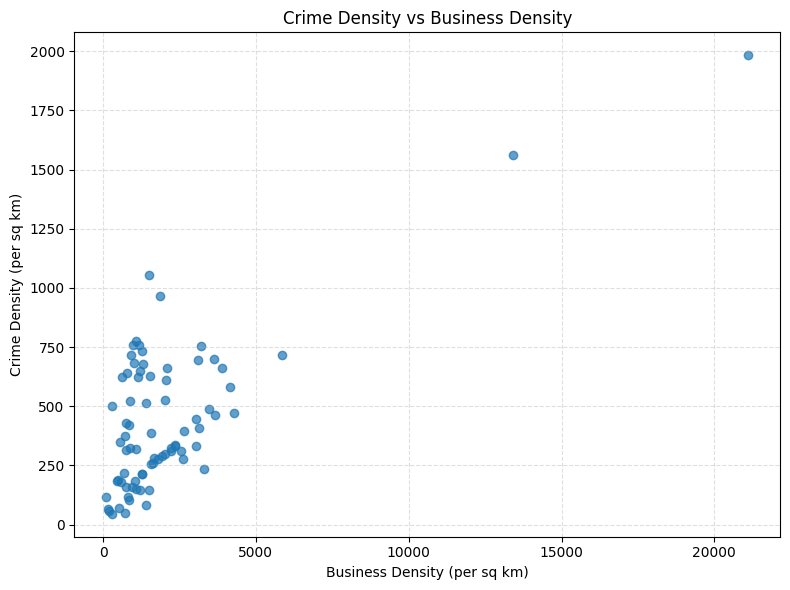

In [8]:
"""
crime_density_sqkm vs business_density_sqkm
"""
path_1 = "Outputs/Crime Density vs Business Density, 2025"
scatter_plot(
    gdf,
    x="business_density_sqkm",
    y="crime_density_sqkm",
    title="Crime Density vs Business Density",
    xlabel="Business Density (per sq km)",
    ylabel="Crime Density (per sq km)",
    save_path=path_1
)

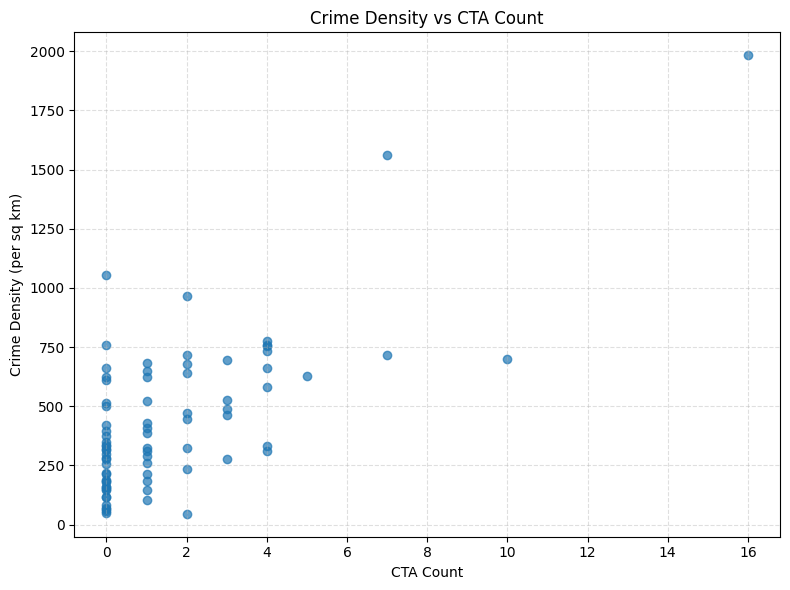

In [12]:
"""
Crime Density vs CTA Count
"""
path_2 = "Outputs/Crime Density vs CTA Count, 2025"
scatter_plot(
    gdf,
    x="cta_count",
    y="crime_density_sqkm",
    title="Crime Density vs CTA Count",
    xlabel="CTA Count",
    ylabel="Crime Density (per sq km)",
    save_path=path_2
)

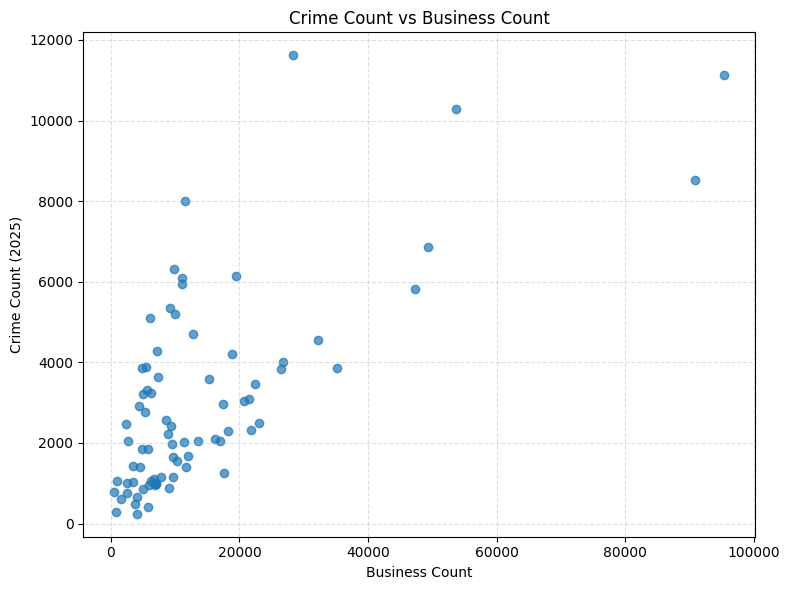

In [13]:
"""
Crime Count vs Business Count
"""
path_3 = "Outputs/Crime Count vs Business Count, 2025"
scatter_plot(
    gdf,
    x="business_count",
    y="crime_count_2025",
    title="Crime Count vs Business Count",
    xlabel="Business Count",
    ylabel="Crime Count (2025)",
    save_path=path_3
)

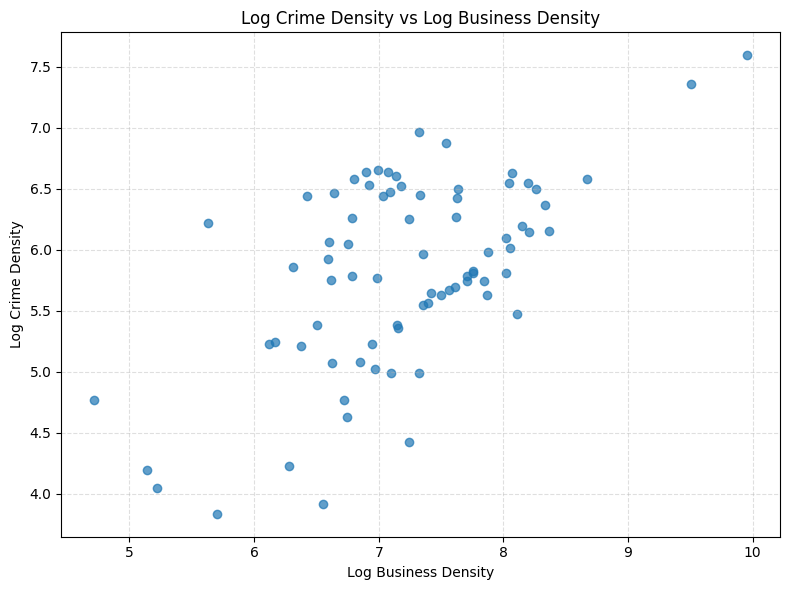

In [14]:
"""
Log Crime Density vs Log Business Density
"""
path_4 = "Outputs/Log Crime Density vs Log Business Density, 2025"
scatter_plot(
    gdf,
    x="log_business_density",
    y="log_crime_density",
    title="Log Crime Density vs Log Business Density",
    xlabel="Log Business Density",
    ylabel="Log Crime Density",
    save_path=path_4
)

#### Optional but strongly recommended: add a fitted line

This makes the pattern easier to interpret.

In [18]:
# Use it especially for the log-log version:
def scatter_with_fit(df, x, y, title, xlabel=None, ylabel=None, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df[x], df[y], alpha=0.7)

    # simple fitted line
    z = np.polyfit(df[x], df[y], 1)
    p = np.poly1d(z)
    x_vals = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(x_vals, p(x_vals), linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel else x)
    ax.set_ylabel(ylabel if ylabel else y)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        
    plt.show()

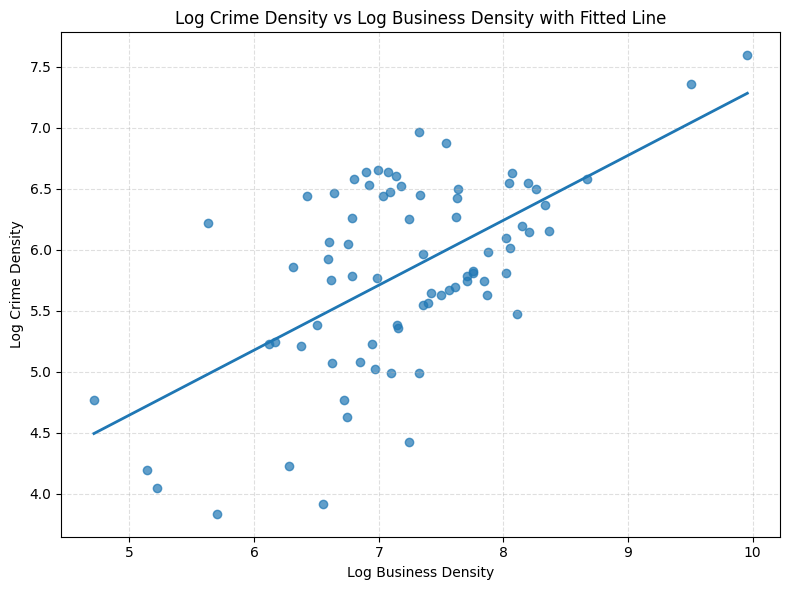

In [19]:
"""
Log Crime Density vs Log Business Density with Fitted Line
"""
path_5 = "Outputs/Log Crime Density vs Log Business Density with Fitted Line, 2025"
scatter_with_fit(
    gdf,
    x="log_business_density",
    y="log_crime_density",
    title="Log Crime Density vs Log Business Density with Fitted Line",
    xlabel="Log Business Density",
    ylabel="Log Crime Density",
    save_path=path_5
)

## Interpret the scatter plots

What you should look for:

**If raw-density scatter is very skewed** That usually means a few high-intensity areas are dominating the trend.

**If the log-log scatter still shows a clear positive slope**That is much stronger evidence that the relationship is not only a downtown outlier effect.

**If crime_density_sqkm vs cta_count is also positive** That suggests transit accessibility may also be associated with higher crime concentration.

**If crime_count_2025 vs business_count is stronger than density-vs-density** That may indicate a simple size/activity effect rather than a true spatial intensity effect.

## Create the OLS diagnostic model

This is not your final causal model. It is only a diagnostic to see whether business density still matters after adding transport and police variables.

**Model specification**

$$Y=log(1+crime\_density\_sqkm)$$
$$X=log(1+business\_density\_sqkm), cta\_count, police\_count$$


In [22]:
# !pip install statsmodels

In [23]:
import statsmodels.api as sm

ols_df = gdf[[
    "log_crime_density",
    "log_business_density",
    "cta_count",
    "police_count"
]].dropna().copy()

X = ols_df[["log_business_density", "cta_count", "police_count"]]
X = sm.add_constant(X)

y = ols_df["log_crime_density"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_crime_density   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     16.55
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.66e-08
Time:                        14:50:40   Log-Likelihood:                -69.785
No. Observations:                  77   AIC:                             147.6
Df Residuals:                      73   BIC:                             156.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.7143 

In [33]:
# save coefficients for later use
coef_table = pd.DataFrame({
    "variable": model.params.index,
    "coefficient": model.params.values,
    "p_value": model.pvalues.values
})
coef_table.to_csv("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/tables/ols_diagnostic_coefficients.csv", index=False)

## Analyze the OLS result
From the OLS output:

- Dependent variable: log_crime_density
- R-squared = 0.405
- Adj R-squared = 0.380
- Prob(F-statistic) = 2.66e-08

**Interpretation**

```text
About 40.5% of the variation in crime density across Chicago community areas can be explained by business density, CTA density, and police stations. The model is statistically significant overall.
```

For Urban spatial data, R² ≈ 0.40 is actually quite reasonable.

So this already supports our project idea: **Crime distribution is not random -- it is related to urban activity infrastructure.**

### Interpret each variable
**(1) log_business_density**

```
coef = 0.4085
p-value = 0.000
```
This is statistically significant.

Because both variables are in log form:
```
A 1% increase in business density is associated with approximately a 0.41% increase in crime density, holding CTA and police constant.
```

For report content:
```
The regression results indicate that business density is positively and significantly associated with crime density across community area. This suggests that areas with higher commercial activity tend to experience higher crime intensity, possibly due to increased human activity, opportunities for theft, and transportation accessibility.
```

**(2) cta_count**

```
coef = 0.0592
p-value = 0.110
```

Not significant at 0.05 level, but close.

**Interpretation** 

CTA stations may have a positive relationship with crime, but once business density is included, the independent effect becomes weaker.

This actually makes sense: **Transit stations and business areas are  spatially correlated (downtown, commercial corridors).**

So business density may already capture much of the activity intensity.

```
The number of CTA stations shows a positive but statistically insignificant relationships with crime density after controlling for business density, suggesting that transit accessibility alone may not independently explain crime concentration when commercial activity is considered.
```

**(3) police_count**

```
coef = 0.2182
p-value = 0.176
```

Not significant.

**Interpretation**

This does NOT mean police cause crime.

Instead, it usually means: **police stations are located in areas with historically higher crime or higher activity levels.**

This is called reverse causality / spatial allocation effect.

```
Police station counts are positively associated with crime density, although the relationship is not statistically significant. This likely reflects the spatial allocation of police resources to areas with higher crime risk rather than a causual effect of police presence on crime occurence.
```

## The regression equation

The model equation is 

$$log(crime density)=2.714+0.409⋅log(business density)+0.059⋅CTA count+0.218⋅police count$$

This equation is useful for methodology / results section.

#### One very important interpretation sentence

[**Discussion**]The results indicates that crime density in Chicago is strongly associated with business density at the community-area level. While transit accessibility and police presence show positive relationships with crime density, their effects are not statistically sifnificant after controlling for business density. This suggests that commercial activity intensity may be a primary spatial factor associated with crime concentration, supporting the routine activity theory that crime occurs where motivated offenders, suitable targets, and lack of guardianship converge.

## Optional diagnostics (A & B)
**A. Check multicollinearity**

General rule:
- VIF < 5 is usually acceptable
- Very high VIF means variables overlap too much

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)

               variable         VIF
0                 const  105.851811
1  log_business_density    1.662883
2             cta_count    1.769720
3          police_count    1.085737


**B. Save residuals back to polygons**

This is very useful for mapping

Interpretation:

- Positive residual = more crime density than expected
- Negative residual = less crime density than expected

That residual map can become a very nice “unexpected crime burden” layer.

In [26]:
gdf.loc[ols_df.index, "ols_pred_log_crime_density"] = model.predict(X)
gdf.loc[ols_df.index, "ols_residual"] = y - model.predict(X)

## Map the OLS residuals

This helps identify community areas where crime density is unusually high or low after accounting for business densitym CTAm and police presence. 

This map tells:
```
Which areas have more crime than expected given business density and transit?
```
This is very strong for discussion section.

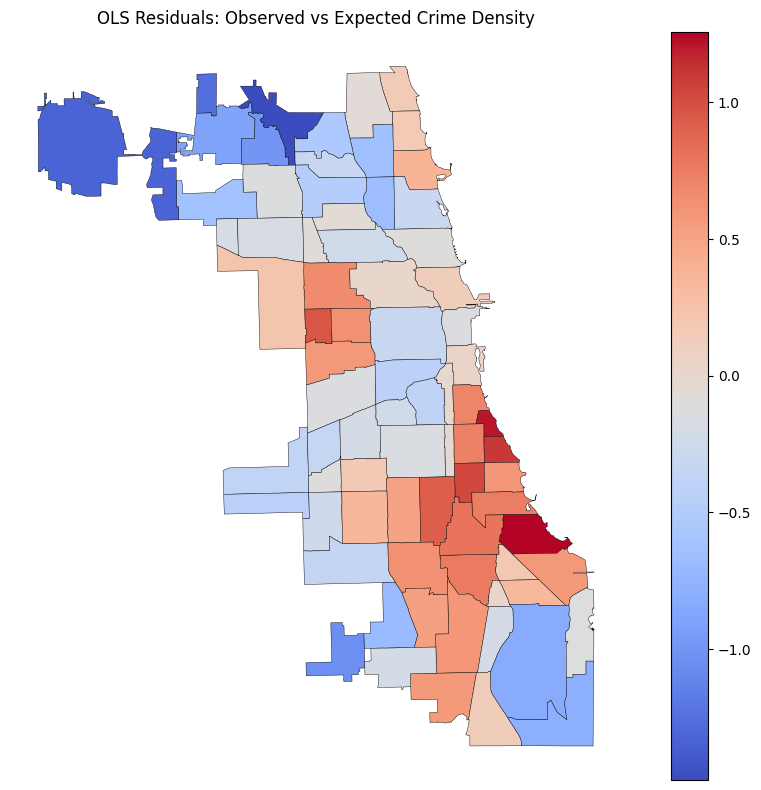

In [32]:
ax = gdf.to_crs("EPSG:4326").plot(
    column="ols_residual",
    cmap="coolwarm",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.3
)
ax.set_title("OLS Residuals: Observed vs Expected Crime Density")
ax.set_axis_off()
plt.tight_layout()
fig = ax.get_figure()
fig.savefig("Outputs/OLS Residuals: Observed vs Expected Crime Density, 2025", dpi=300, bbox_inches="tight")
plt.show()

## What the residual map means

$$Residual = Observed log crime density − Predicted log crime density$$

So:
```
| Color                        | Meaning                  |
| ---------------------------- | ------------------------ |
| Red (positive residual)      | More crime than expected |
| Blue (negative residual)     | Less crime than expected |
| White / grey                 | About as expected        |
```

Expected crime density is based on:
- Business density
- CTA stations
- Police stations

So this map amswers a very important questions:
**Which community areas have unusually high or low crime after accounting for urban activity and infrastructure?**

## Spatial pattern interpretation 

From the map

**Pattern 1** — South / Southeast Chicago (many red areas)

These areas show higher crime than expected even after controlling for:

- Business density
- Transit access
- Police stations

Interpretation:

Crime in these areas cannot be explained only by commercial activity or transit accessibility. Other socio-economic factors such as income inequality, unemployment, housing conditions, or historical segregation patterns may play a stronger role.

This is a very strong discussion point.

**Pattern 2** — Northwest / West Chicago (many blue areas)

These areas have lower crime than expected given their business density and transit access.

Interpretation:

Some areas appear to maintain relatively low crime levels despite comparable levels of commercial activity and accessibility, which may reflect differences in neighborhood socio-economic conditions, urban design, community organization, or policing strategies.

This is also a strong discussion point.

```
The residual map from the OLS regression reveals spatial patterns that are not explained by business density, transit accessibility, and police presence. Several community areas in the southern and southeastern parts of Chicago exhibit higher crime densities than predicted by the model, indicating that additional socio-economic or historical factors may contribute to crime concentration in these areas. In contrast, some northwestern community areas show lower crime densities than expected, suggesting that local community characteristics, urban design, or social cohesion may help reduce crime despite similar levels of urban activity. The residual analysis therefore highlights spatial heterogeneity in crime patterns that cannot be fully explained by infrastructure and business activity alone.
```

In [28]:
# save
gdf.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v3.geojson", driver="GeoJSON")
gdf.to_file("/home/metayj/InternetGIS/CrimeAnalysis/data/processed/vector/community_area_analysis_v3.gpkg", driver="GPKG")

In [29]:
gdf.head()

,AREA_NUMBE,COMMUNITY,area_sqkm,crime_count_2025,cta_count,police_count,business_count,crime_density_sqkm,business_density_sqkm,log_crime_count,log_crime_density,log_business_count,log_business_density,crime_business_profile,geometry,ols_pred_log_crime_density,ols_residual
0,1,ROGERS PARK,4.762220,3582,4.0,1.0,15204,752.170235,3192.628772,8.183956,6.624291,9.629380,8.068913,High crime / High business,"MULTIPOLYGON (((356237.576 592121.821, 356139....",6.465273,0.159018
1,2,WEST RIDGE,9.144399,3087,0.0,0.0,21427,337.583705,2343.183043,8.035279,5.824771,9.972454,7.759692,High crime / High business,"MULTIPOLYGON (((353726.032 594470.382, 353727....",5.883882,-0.059111
2,3,UPTOWN,6.047607,4209,3.0,0.0,18784,695.977731,3106.021787,8.345218,6.546753,9.840814,8.041420,High crime / High business,"MULTIPOLYGON (((357397.618 587314.391, 357151....",6.176585,0.370168
3,4,LINCOLN SQUARE,6.628875,2052,4.0,1.0,16952,309.554802,2557.296784,7.627057,5.738360,9.738200,7.847097,Low crime / High business,"MULTIPOLYGON (((354611.686 589658.442, 354612....",6.374668,-0.636307
4,5,NORTH CENTER,5.300527,1254,2.0,0.0,17565,236.580257,3313.821538,7.134891,5.470505,9.773720,8.106159,Low crime / High business,"MULTIPOLYGON (((354735.595 584798.593, 354731....",6.143821,-0.673316


## Very important conceptual interpretation

This project has three levels of spatial analysis

```
| Level   | Method       | Question                                      |
| ------- | ------------ | --------------------------------------------- |
| Level 1 | KDE          | Where is crime concentrated?                  |
| Level 2 | Choropleth   | Which areas have high crime/business density? |
| Level 3 | OLS          | Does business density explain crime density?  |
| Level 4 | Residual map | Where does the model fail to explain crime?   |
```

Level 4 is advanced spatial thinking.

You are basically doing:

```Spatial pattern → Spatial relationship → Spatial explanation → Spatial anomaly```

## Our project is basically answering the following question

```
To what extent is the spatial distribution of crime in Chicago associated with business activity and urban infrastructure, and which areas exhibit crime levels that cannot be explained by these factors?
```
